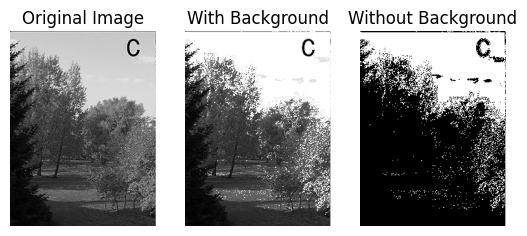

In [ ]:
import cv2
import numpy as np
import matplotlib.pyplot as plt
from google.colab.patches import cv2_imshow

#Gray Level Slicing

gray_img=cv2.imread("/content/gray_level_slicing.bmp",0)

upper=220
lower=125

wbg_img=gray_img.copy()
nbg_img=gray_img.copy()

rows,col=gray_img.shape

for i in range(rows):
  for j in range(col):

    if lower<= gray_img[i][j] <=upper:
      nbg_img[i][j]=255
    else:
      nbg_img[i][j]=0

    if lower<= gray_img[i][j] <=upper:
      wbg_img[i][j]=255
    else:
      wbg_img[i][j]=gray_img[i][j]

plt.subplot(1,3,1)
plt.imshow(gray_img,cmap="gray")
plt.title("Original Image")
plt.axis("off")

plt.subplot(1,3,2)
plt.imshow(wbg_img,cmap="gray")
plt.title("With Background")
plt.axis("off")

plt.subplot(1,3,3)
plt.imshow(nbg_img,cmap="gray")
plt.title("Without Background")
plt.axis("off")
plt.show()

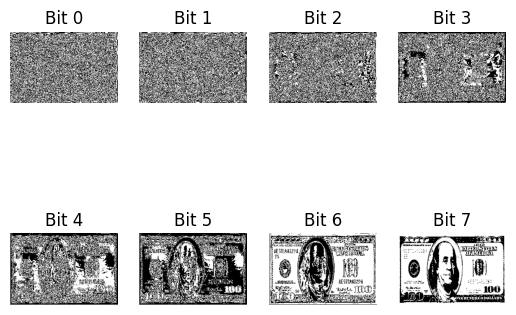

In [ ]:
#Bit Plane Slicing

original_bit_img=cv2.imread("/content/bit_plane_slicing.bmp",0)

bit_matrix=np.array(original_bit_img)
rows,col=bit_matrix.shape

for k in range(8):

  bit_img=original_bit_img.copy()

  for i in range(rows):
    for j in range(col):

      pixel=original_bit_img[i][j]

      bit=(pixel>>k) & 1

      bit_img[i][j] = 255 if bit == 1 else 0

  plt.subplot(2,4,k+1)
  plt.imshow(bit_img, cmap='gray')
  plt.title(f'Bit {k}')
  plt.axis('off')


plt.show()







91 136


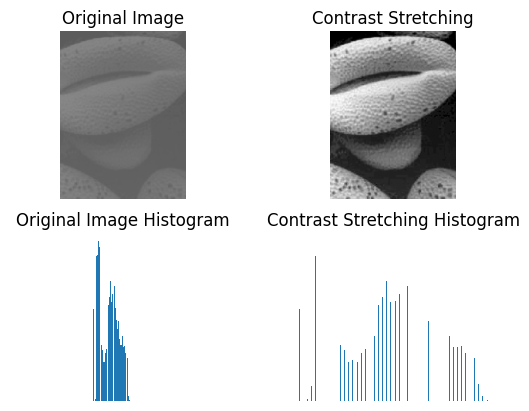

In [ ]:
original_contrast_img=cv2.imread("/content/contrast.bmp",1)
original_contrast_img2=cv2.imread("/content/contrast.bmp",0)

min_val=np.min(original_contrast_img)
max_val=np.max(original_contrast_img)
print(min_val, max_val)

contrast_img = original_contrast_img2.copy()

contrast_matrix=np.array(contrast_img)

rows,col=contrast_matrix.shape

r1,r2=91,136
s1,s2=10,245

for i in range(rows):
  for j in range(col):

    r=original_contrast_img2[i][j]

    if r<=r1:
      contrast_img[i][j]=(s1/r1)*r

    elif r<=r2:
      contrast_img[i][j]=((s2-s1)/(r2-r1))*(r - r1)+s1

    else:
      contrast_img[i][j]=((255-s2)/(255-r2))*(r-r2)+s2


plt.subplot(2,2,1)
plt.imshow(original_contrast_img, cmap='gray')
plt.title("Original Image")
plt.axis('off')


plt.subplot(2,2,2)
plt.imshow(contrast_img, cmap='gray')
plt.title("Contrast Stretching")
plt.axis('off')

plt.subplot(2,2,3)
plt.hist(original_contrast_img.ravel(),bins=256,range=(0,256))
plt.title("Original Image Histogram")
plt.axis('off')

plt.subplot(2,2,4)
plt.hist(contrast_img.ravel(),bins=256,range=(0,256))
plt.title("Contrast Stretching Histogram")
plt.axis('off')
plt.show()
